<a href="https://colab.research.google.com/github/ManuelRomero2025/Programaci-nPython20254/blob/main/penguins20262.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Asegúrate de haber montado Google Drive previamente
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
url="/content/drive/MyDrive/LosLibertadores20252/penguins.csv"
df=pd.read_csv(url)

In [8]:
df.head()# los primero 5 datos

,Unnamed: 0,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,4,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         344 non-null    int64  
 1   species            344 non-null    object 
 2   island             344 non-null    object 
 3   bill_length_mm     342 non-null    float64
 4   bill_depth_mm      342 non-null    float64
 5   flipper_length_mm  342 non-null    float64
 6   body_mass_g        342 non-null    float64
 7   sex                333 non-null    object 
 8   year               344 non-null    int64  
dtypes: float64(4), int64(2), object(3)
memory usage: 24.3+ KB


In [10]:
#duplicados
df.drop_duplicates()

,Unnamed: 0,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,4,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
...,...,...,...,...,...,...,...,...,...
339,340,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009
340,341,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
341,342,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
342,343,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009


In [11]:
df.isnull().sum()

,0
Unnamed: 0,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11
year,0


In [12]:
df=df.dropna()# eliminar los na
df.isnull().sum()

,0
Unnamed: 0,0
species,0
island,0
bill_length_mm,0
bill_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,0
year,0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         333 non-null    int64  
 1   species            333 non-null    object 
 2   island             333 non-null    object 
 3   bill_length_mm     333 non-null    float64
 4   bill_depth_mm      333 non-null    float64
 5   flipper_length_mm  333 non-null    float64
 6   body_mass_g        333 non-null    float64
 7   sex                333 non-null    object 
 8   year               333 non-null    int64  
dtypes: float64(4), int64(2), object(3)
memory usage: 26.0+ KB


In [14]:
df.shape

(333, 9)

In [15]:
df.describe()

,Unnamed: 0,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000
mean,174.324324,43.992793,17.164865,200.966967,4207.057057,2008.042042
std,98.386547,5.468668,1.969235,14.015765,805.215802,0.812944
min,1.000000,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,90.000000,39.500000,15.600000,190.000000,3550.000000,2007.000000
50%,173.000000,44.500000,17.300000,197.000000,4050.000000,2008.000000
75%,259.000000,48.600000,18.700000,213.000000,4775.000000,2009.000000
max,344.000000,59.600000,21.500000,231.000000,6300.000000,2009.000000


In [16]:
df.describe(include="object")

,species,island,sex
count,333,333,333
unique,3,3,2
top,Adelie,Biscoe,male
freq,146,163,168


In [17]:
#Tabla de fecuencia absoluta
cantidad=df["sex"].value_counts()
print(cantidad)

sex
male      168
female    165
Name: count, dtype: int64


* "Manuel"
* "Manuel "
* " Manuel"
* " Manuel "

In [37]:
cantidad=(df["sex"].astype(str).str.strip().str.title().value_counts().sort_index())
#.astype(str)Convierte todos los valores de la columna en tipo texto (string).
#.str.strip() Elimina espacios innecesarios al inicio y al final del texto.
#.str.title() Convierte la primera letra en mayúscula y las demás en minúscula.
#.value_counts() Cuenta cuántas veces aparece cada categoría.
#.sort_index() Ordena las categorías según el índice (nombre de categoría).
cantidad

,count
sex,
Female,165
Male,168


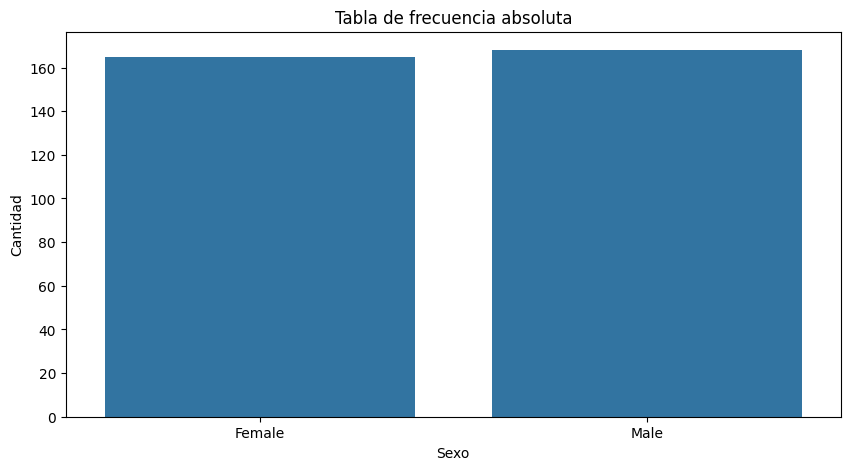

In [19]:
plt.figure(figsize=(10,5))
sns.barplot(x=cantidad.index,
            y=cantidad.values)
plt.xlabel("Sexo")# Etiqueta del eje x
plt.ylabel("Cantidad")# etiqueta del eje y
plt.title("Tabla de frecuencia absoluta") #Título
plt.show()

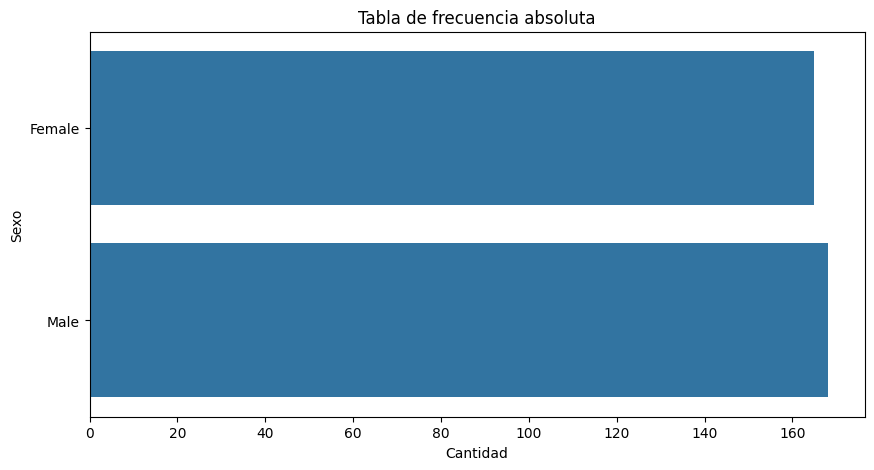

In [20]:
plt.figure(figsize=(10,5))
sns.barplot(y=cantidad.index,
            x=cantidad.values)
plt.ylabel("Sexo")# Etiqueta del eje x
plt.xlabel("Cantidad")# etiqueta del eje y
plt.title("Tabla de frecuencia absoluta") #Título
plt.show()

In [21]:
#frecuencia relativasm, porcentaje o con probabilidades
fr=(df["sex"].astype(str).str.strip().str.title().value_counts())
fr

,count
sex,
Male,168
Female,165


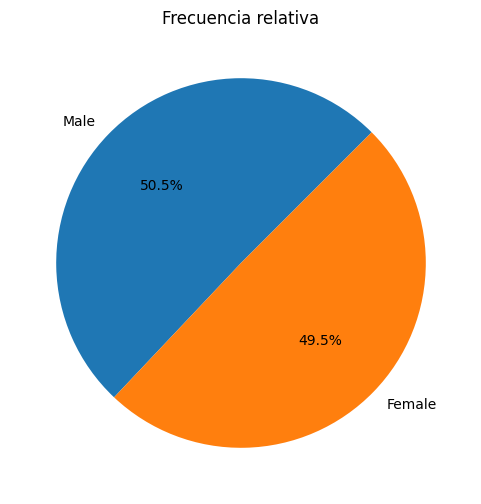

In [22]:
plt.figure(figsize=(6,6))
plt.pie(fr.values.tolist(),
        labels=fr.index.tolist(),
        autopct="%1.1f%%", startangle=45)
plt.title("Frecuencia relativa")
plt.show()

In [23]:
#frecuencia relativasm, porcentaje o con probabilidades
frSpe=(df["species"].astype(str).str.strip().str.title().value_counts())
frSpe

,count
species,
Adelie,146
Gentoo,119
Chinstrap,68


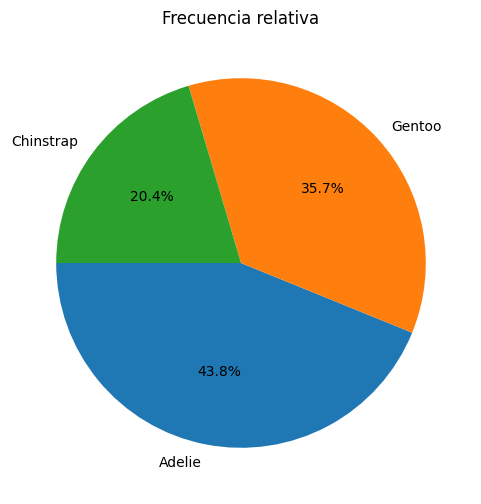

In [24]:
plt.figure(figsize=(6,6))
plt.pie(frSpe.values.tolist(),
        labels=frSpe.index.tolist(),
        autopct="%1.1f%%",
        startangle=180)
plt.title("Frecuencia relativa")
plt.show()

In [25]:
tabla=pd.crosstab(df["sex"].astype(str).str.strip().str.title(),
                  df["species"].astype(str).str.strip().str.title())
tabla

species,Adelie,Chinstrap,Gentoo
sex,,,
Female,73,34,58
Male,73,34,61


In [26]:
tabla1=pd.crosstab(df["sex"].astype(str).str.strip().str.title(),
                  df["species"].astype(str).str.strip().str.title(),
                  margins=True)
tabla1

species,Adelie,Chinstrap,Gentoo,All
sex,,,,
Female,73,34,58,165
Male,73,34,61,168
All,146,68,119,333


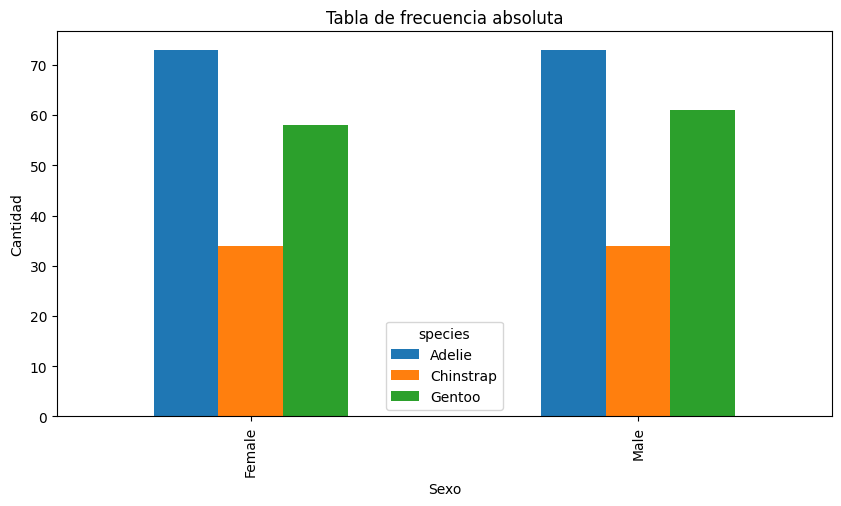

In [27]:
fig1=tabla.plot(kind="bar", stacked=False, figsize=(10,5))
fig1.set_xlabel("Sexo")
fig1.set_ylabel("Cantidad")
fig1.set_title("Tabla de frecuencia absoluta")
plt.show()

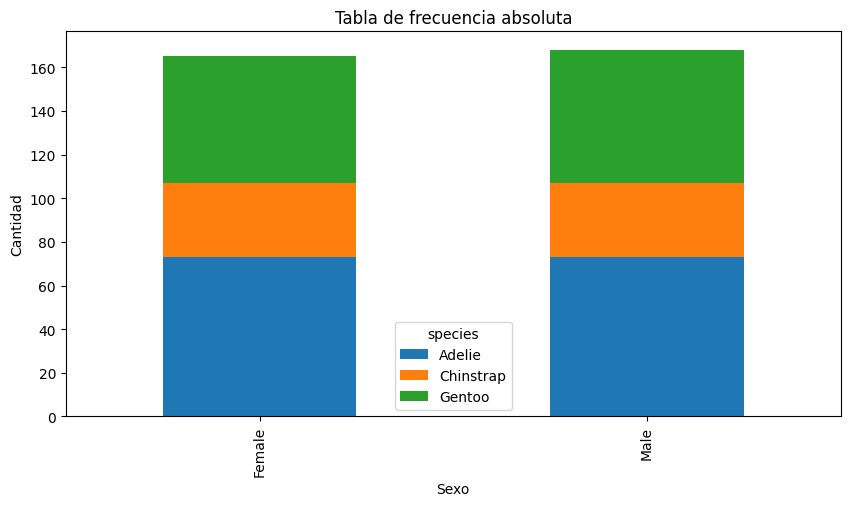

In [28]:
fig1=tabla.plot(kind="bar", stacked=True, figsize=(10,5))
fig1.set_xlabel("Sexo")
fig1.set_ylabel("Cantidad")
fig1.set_title("Tabla de frecuencia absoluta")
plt.show()

You previously calculated `tablaProp` with `normalize='columns'`, meaning the proportions sum to 1 for each species (column).

If you intended to see the proportion of each species *within each sex* (so that the proportions for each row sum to 1), you should use `normalize='index'`.

In [29]:
tablaProp= pd.crosstab(df["sex"].astype(str).str.strip().str.title(),
                               df["species"].astype(str).str.strip().str.title(),
                               normalize="index")# por filas
tablaProp

species,Adelie,Chinstrap,Gentoo
sex,,,
Female,0.442424,0.206061,0.351515
Male,0.434524,0.202381,0.363095


Text(0.5, 1.0, 'Proporción de especies por sexo')

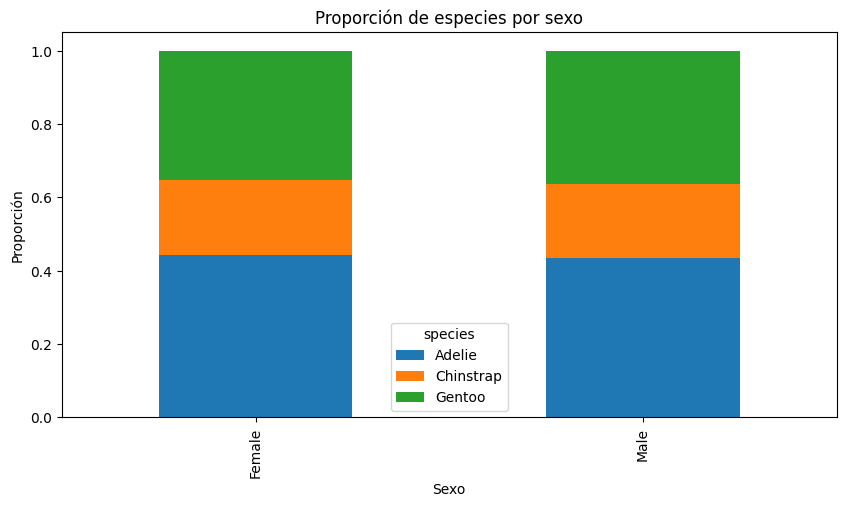

In [30]:
fig2=tablaProp.plot(kind="bar", stacked=True, figsize=(10,5))
fig2.set_xlabel("Sexo")
fig2.set_ylabel("Proporción")
fig2.set_title("Proporción de especies por sexo")

In [31]:
props=pd.crosstab(
    df['species'].astype(str).str.strip().str.title(),
    df['sex'].astype(str).str.strip().str.title(),
    normalize="columns"
)*100
props

sex,Female,Male
species,,
Adelie,44.242424,43.452381
Chinstrap,20.606061,20.238095
Gentoo,35.151515,36.309524


Text(0.5, 1.0, 'Proporción de especies por sexo')

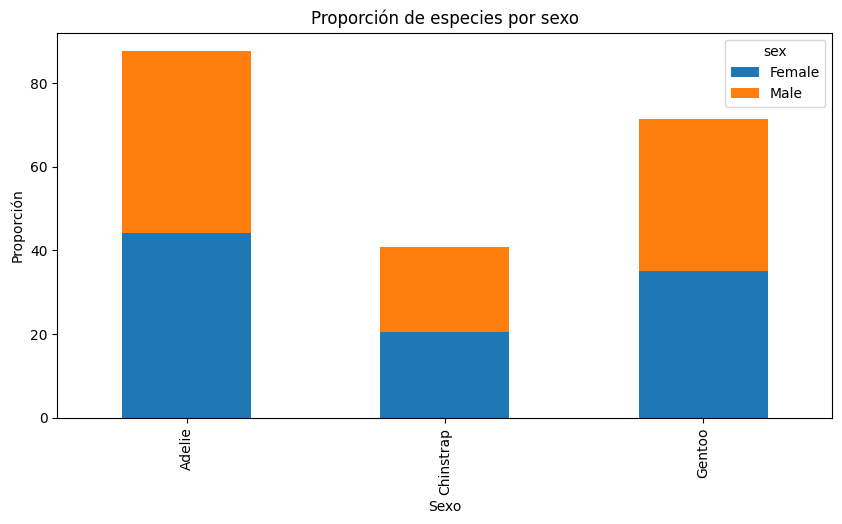

In [38]:
fig3=props.plot(kind="bar", stacked=True, figsize=(10,5))
fig3.set_xlabel("Sexo")
fig3.set_ylabel("Proporción")
fig3.set_title("Proporción de especies por sexo")

# Tabla de Distribución de frecuencia

In [41]:
n=df.shape[0]
n

333

In [42]:
#sturges
clase=int(1+3.33*np.log10(n))
clase

9

In [57]:
intervalos=pd.cut(df['body_mass_g'],
                  bins=clase,
                  right=False)
intervalos.head(10)

,body_mass_g
0,"[3500.0, 3900.0)"
1,"[3500.0, 3900.0)"
2,"[3100.0, 3500.0)"
4,"[3100.0, 3500.0)"
5,"[3500.0, 3900.0)"
6,"[3500.0, 3900.0)"
7,"[4300.0, 4700.0)"
12,"[3100.0, 3500.0)"
13,"[3500.0, 3900.0)"
14,"[4300.0, 4700.0)"


In [60]:
frabs=intervalos.value_counts().sort_index()
#frabs
FrRe=intervalos.value_counts(normalize=True).sort_index()
#FrRe
FrAcu=frabs.cumsum()
#FrAcu
tabla2=pd.DataFrame({
    "Intervalos":frabs,
    "Frecuencia Relativa":FrRe,
    "Frecuencia Acumulada":FrAcu})
tabla2


,Intervalos,Frecuencia Relativa,Frecuencia Acumulada
body_mass_g,,,
"[2700.0, 3100.0)",15,0.045045,15
"[3100.0, 3500.0)",53,0.159159,68
"[3500.0, 3900.0)",72,0.216216,140
"[3900.0, 4300.0)",53,0.159159,193
"[4300.0, 4700.0)",43,0.129129,236
"[4700.0, 5100.0)",39,0.117117,275
"[5100.0, 5500.0)",25,0.075075,300
"[5500.0, 5900.0)",27,0.081081,327
"[5900.0, 6303.6)",6,0.018018,333


<Axes: xlabel='body_mass_g', ylabel='Frecuencia Relativa'>

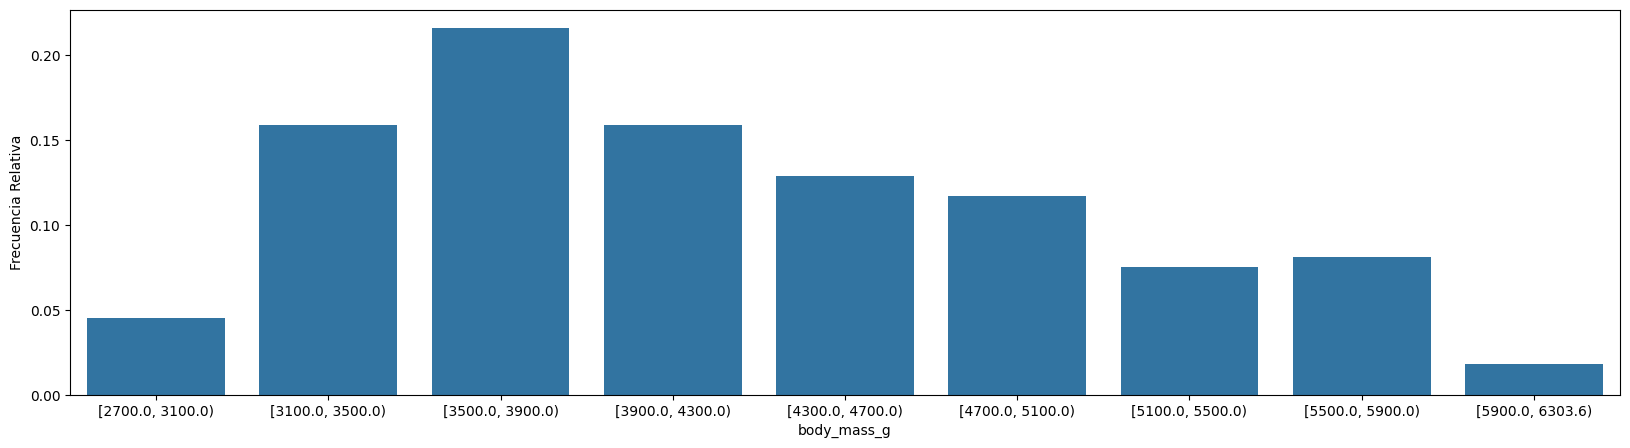

In [62]:
plt.figure(figsize=(20,5))
sns.barplot(x=tabla2.index,
            y=tabla2["Frecuencia Relativa"])

<Axes: xlabel='body_mass_g', ylabel='Intervalos'>

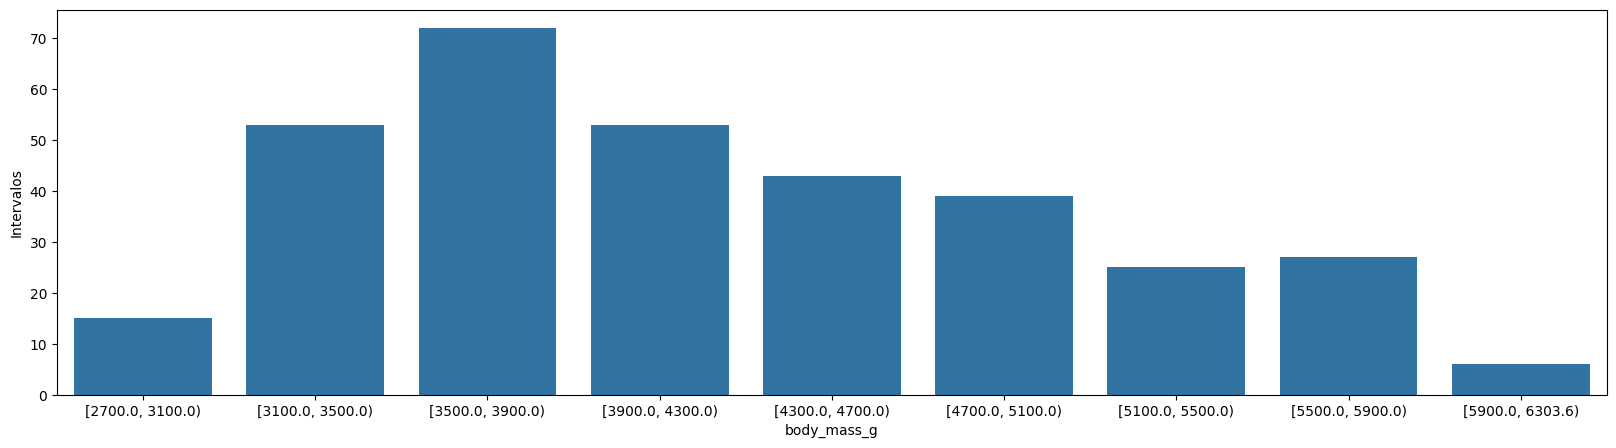

In [63]:
plt.figure(figsize=(20,5))
sns.barplot(x=tabla2.index,
            y=tabla2["Intervalos"])

<Axes: xlabel='body_mass_g', ylabel='Frecuencia Acumulada'>

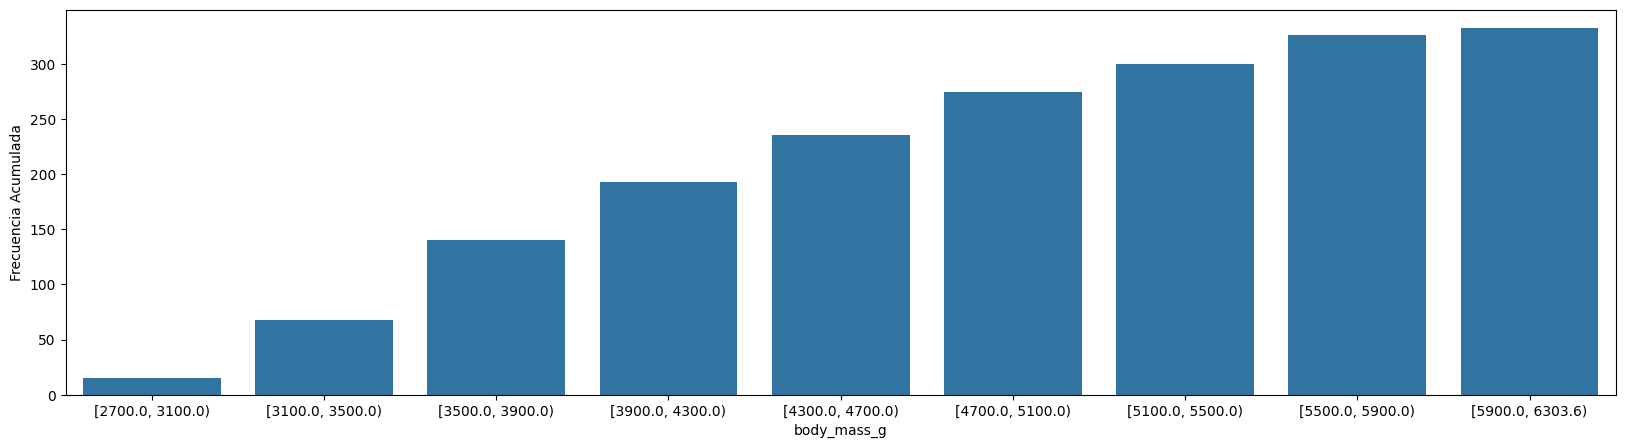

In [64]:
plt.figure(figsize=(20,5))
sns.barplot(x=tabla2.index,
            y=tabla2["Frecuencia Acumulada"])

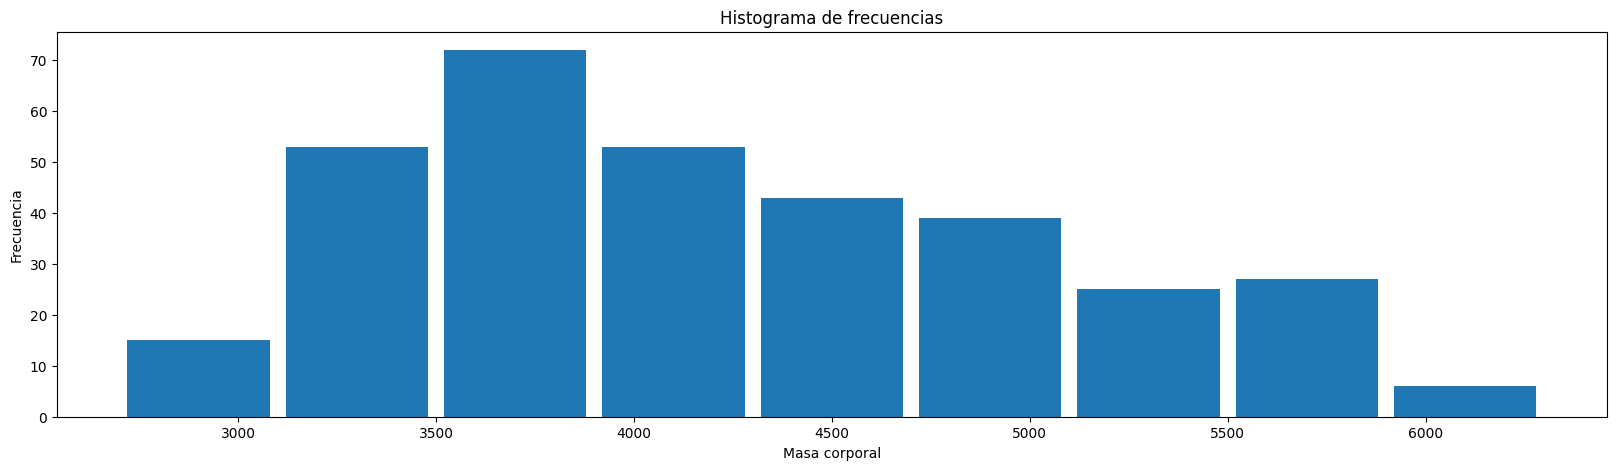

In [69]:
plt.figure(figsize=(20,5))
plt.hist(df['body_mass_g'], bins=clase, rwidth=0.9)
plt.xlabel("Masa corporal")
plt.ylabel("Frecuencia")
plt.title("Histograma de frecuencias")
plt.show()


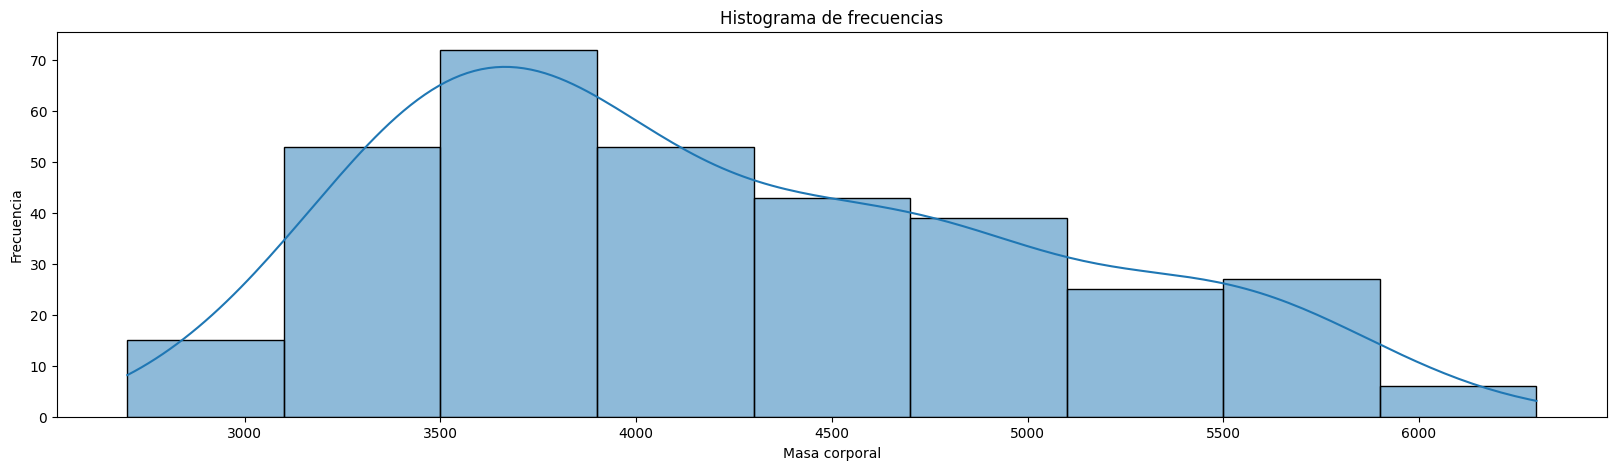

In [72]:
plt.figure(figsize=(20,5))
sns.histplot(df['body_mass_g'], bins=clase, kde=True)
plt.xlabel("Masa corporal")
plt.ylabel("Frecuencia")
plt.title("Histograma de frecuencias")
plt.show()

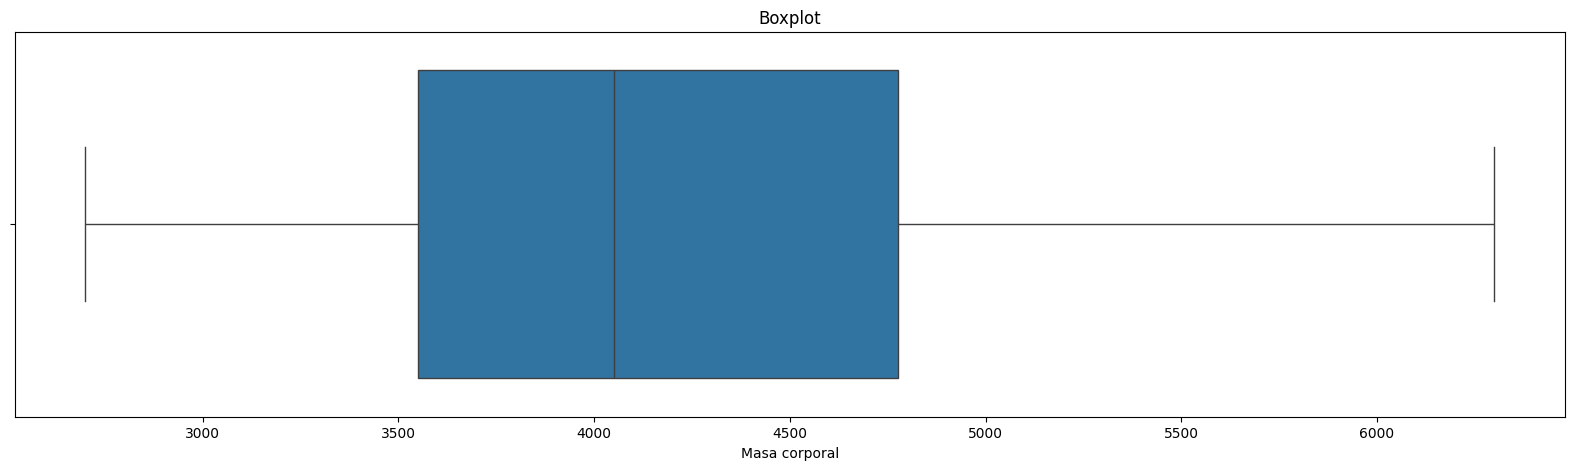

In [76]:
plt.figure(figsize=(20,5))
sns.boxplot(x=df['body_mass_g'])
plt.xlabel("Masa corporal")
plt.title("Boxplot")
plt.show()

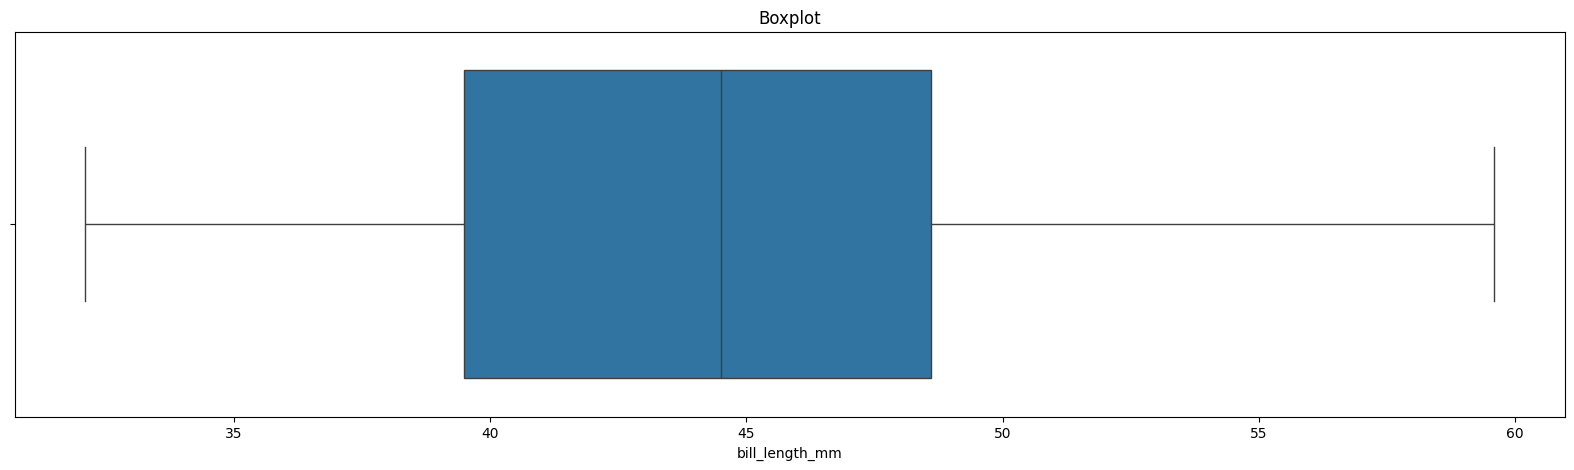

In [78]:
plt.figure(figsize=(20,5))
sns.boxplot(x=df["bill_length_mm"])
plt.xlabel("bill_length_mm")
plt.title("Boxplot")
plt.show()

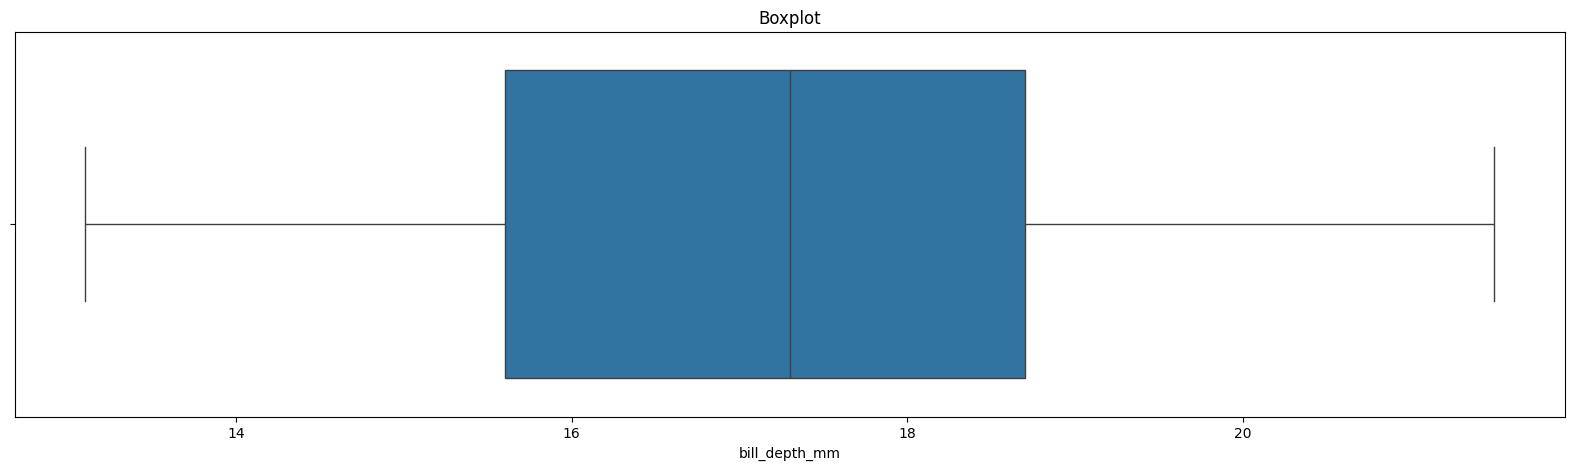

In [79]:
plt.figure(figsize=(20,5))
sns.boxplot(x=df["bill_depth_mm"])
plt.xlabel("bill_depth_mm")
plt.title("Boxplot")
plt.show()

Text(0.5, 1.0, 'Boxplot')

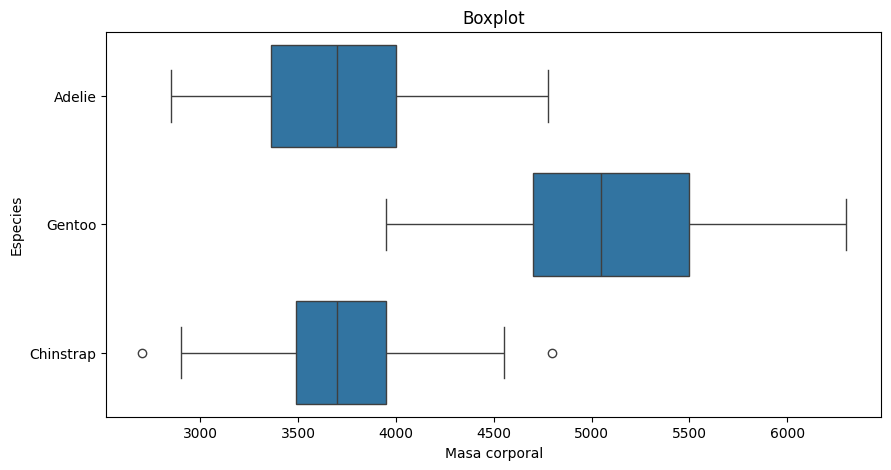

In [86]:
plt.figure(figsize=(10,5))
fig4=sns.boxplot(x="body_mass_g", y="species", data=df)
fig4.set_xlabel("Masa corporal")
fig4.set_ylabel("Especies")
fig4.set_title("Boxplot")

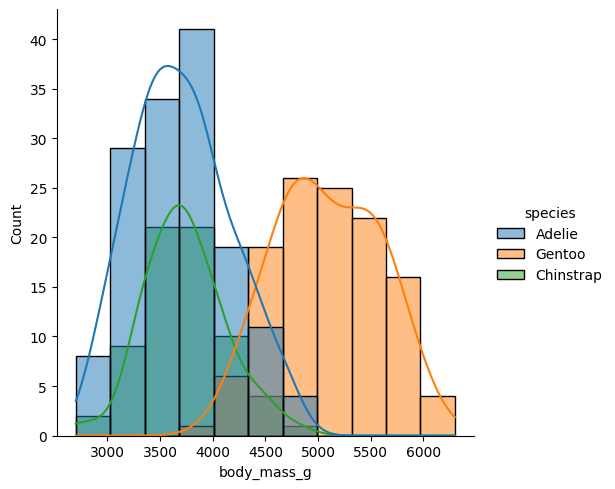

In [87]:
fig5=sns.displot(data=df,
                 x="body_mass_g",
                 hue="species",
                 kind="hist",
                 kde=True)

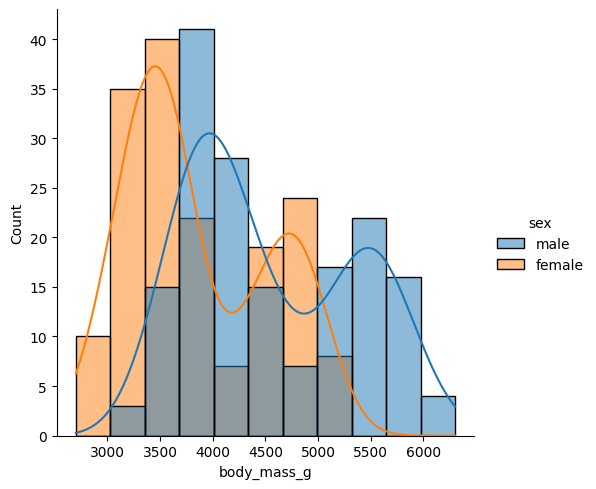

In [88]:
fig6=sns.displot(data=df,
                 x="body_mass_g",
                 hue="sex",
                 kind="hist",
                 kde=True)

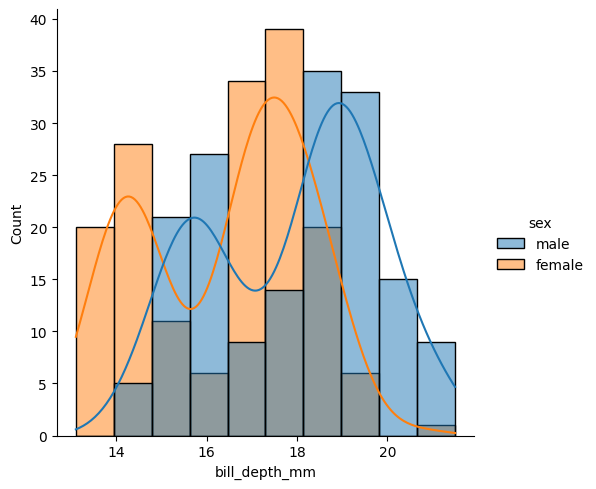

In [89]:
fig7=sns.displot(data=df,
                 x="bill_depth_mm",
                 hue="sex",
                 kind="hist",
                 kde=True)

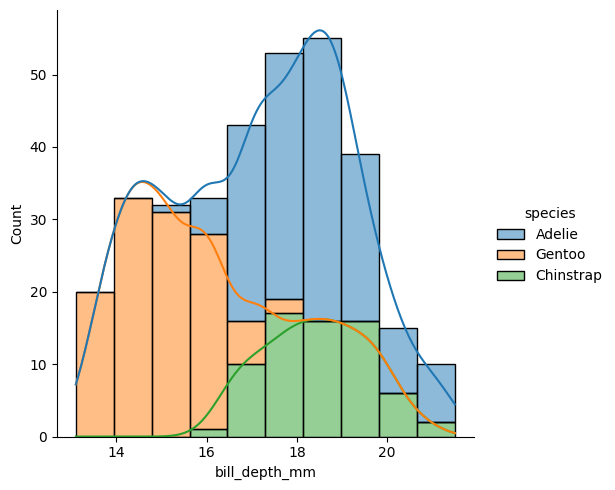

In [92]:
fig8=sns.displot(data=df,
                 x="bill_depth_mm",
                 hue="species",
                 kind="hist",
                 multiple="stack",
                 kde=True)

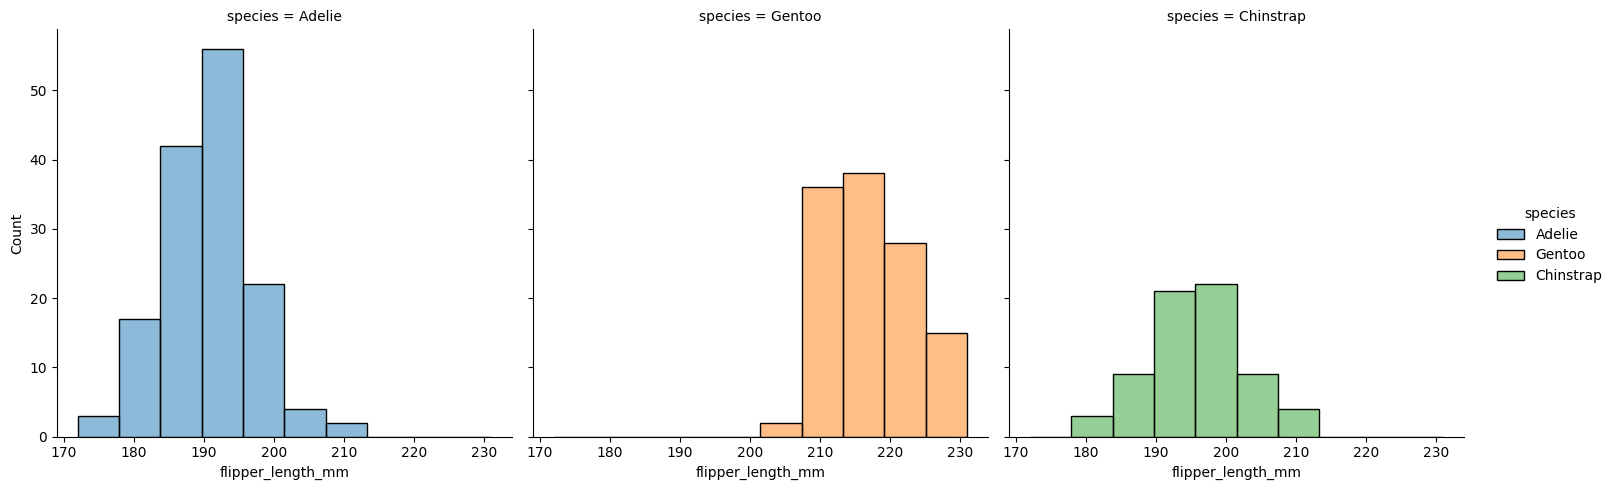

In [93]:
sns.displot(data=df, x="flipper_length_mm", hue="species", col="species")

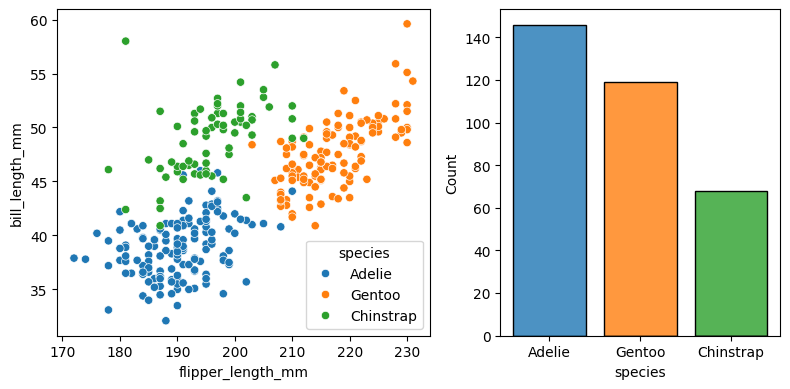

In [94]:
f, axs = plt.subplots(1, 2, figsize=(8, 4), gridspec_kw=dict(width_ratios=[4, 3]))
sns.scatterplot(data=df, x="flipper_length_mm", y="bill_length_mm", hue="species", ax=axs[0])
sns.histplot(data=df, x="species", hue="species", shrink=.8, alpha=.8, legend=False, ax=axs[1])
f.tight_layout()

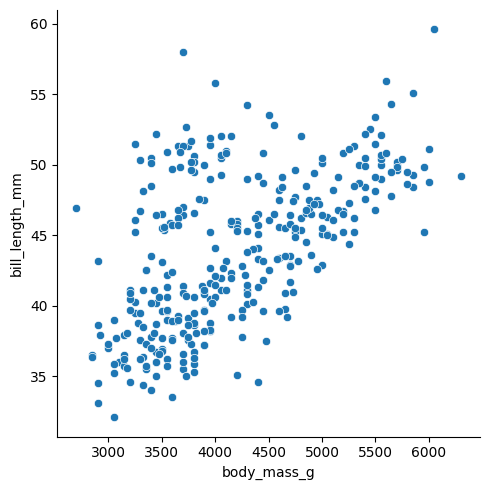

In [97]:
sns.relplot(data=df, x="body_mass_g", y="bill_length_mm")

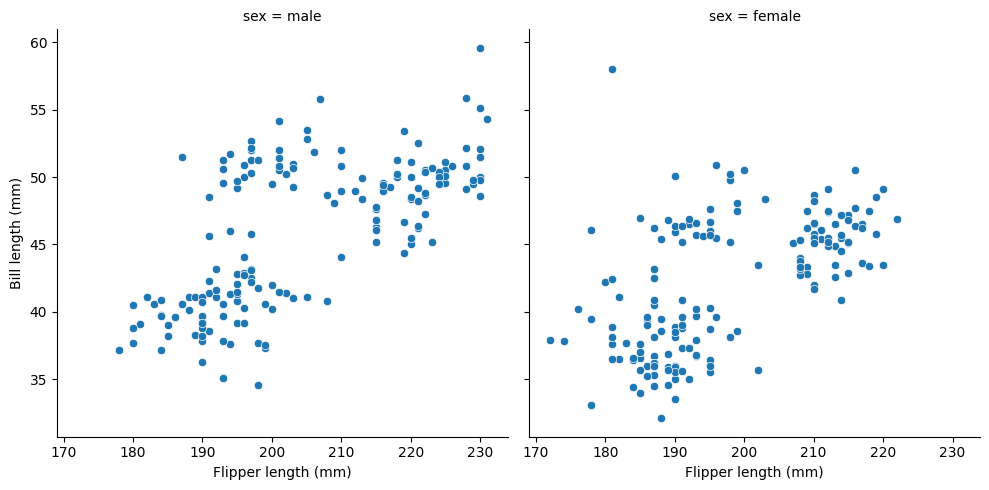

In [98]:
g = sns.relplot(data=df, x="flipper_length_mm", y="bill_length_mm", col="sex")
g.set_axis_labels("Flipper length (mm)", "Bill length (mm)")